


---


# Combina duas coleções de imagens: coleção de precipipitação do GPM (11132 metros) e CHIRPS (5566 metros) para uma resolução espacial de 20 km



---



- Exemplo retirado de: https://www.youtube.com/watch?v=T3UGQfl57vc&list=PLMFUNkj5z2c4tQaJjKMju7PX0rs8UOVoK&index=2


---


- Dados utilizados:
    1. `GPM`: https://developers.google.com/earth-engine/datasets/catalog/NASA_GPM_L3_IMERG_MONTHLY_V07?hl=pt-br
    2. `CHIRPS`: https://developers.google.com/earth-engine/datasets/catalog/UCSB-CHG_CHIRPS_DAILY?hl=pt-br


---




# Instalando Xee e inicializando GEE

Se você tiver uma conta do Earth Engine você poderá encontrar a sua ID de um projeto do GEE acessando https://code.earthengine.google.com/ com sua conta google, e depois verificando do lado superior direito do Code Editor o nome da sua ID.

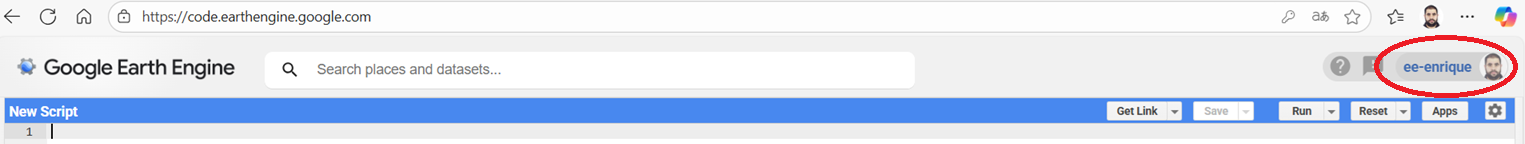

Insira a sua ID no campo `geemap.ee_initialize(project='SUA ID')`.

In [1]:
# instalando Xee
!pip install -q xee

# importa bibliotecas
import ee
import geemap
import xee
import xarray as xr
import time

# inicializando pelo GEE
geemap.ee_initialize(project='ee-enrique', opt_url='https://earthengine-highvolume.googleapis.com')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 9.8 MB/s eta 0:00:00


# Processamento

- Dados utilizados:
    1. `GPM`: https://developers.google.com/earth-engine/datasets/catalog/NASA_GPM_L3_IMERG_MONTHLY_V07?hl=pt-br
    2. `CHIRPS`: https://developers.google.com/earth-engine/datasets/catalog/UCSB-CHG_CHIRPS_DAILY?hl=pt-br


- Carregando os dados de 2020 à 2025 (2020, 2021, 2022, 2023, 2024 e 2025).

In [30]:
%%time
# período dos dados
data_inicial = ee.Date('2020')
data_final = ee.Date('2026')

# diferença de datas
data_dif = data_final.difference(data_inicial, 'year').round()

# listas dos anos
lista_datas = ee.List.sequence(0, ee.Number(data_dif).subtract(1)).map(lambda x: data_inicial.advance(x, 'year'))

# função de acumulação anual
def anual(data, col):
    data_i = ee.Date(data)
    data_f = data_i.advance(1, 'year')
    soma = col.filterDate(data_i, data_f).sum()
    return soma.set('system:time_start', data_i.millis())

# define a região de interesse: queremos a área do Brasil
brasil = ee.FeatureCollection('FAO/GAUL/2015/level0').filter(ee.Filter.eq('ADM0_NAME', 'Brazil'))

# GPM
# Obs: Os dados do GPM são mensais e estão em mm/h. Para coneverter para mm/mês multiplicaremos as imagens mensais (mm/h) por "730".
gpm = ee.ImageCollection("NASA/GPM_L3/IMERG_MONTHLY_V07") \
        .filterDate(data_inicial, data_final) \
        .select(['precipitation'], ['precip_gpm']) \
        .map(lambda img: img.multiply(730).copyProperties(img, ['system:time_start'])) \
        .map(lambda img: img.clip(brasil).copyProperties(img, img.propertyNames()))

# CHIRPS
chirps = ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY') \
           .filterDate(data_inicial, data_final) \
           .select(['precipitation'], ['precip_chirps']) \
           .map(lambda img: img.clip(brasil).copyProperties(img, img.propertyNames()))

# acumula anual
gpm_anual = ee.ImageCollection(lista_datas.map(lambda x: anual(x, gpm)))
chirps_anual = ee.ImageCollection(lista_datas.map(lambda x: anual(x, chirps)))

# combina GPM e CHIRPS
gpm_chirps = gpm_anual.combine(chirps_anual)

# gera dataset com resolução espacial de 20km
ds = xr.open_dataset(gpm_chirps,
                     engine = 'ee',
                     crs = 'EPSG:4326',
                     scale = 0.2,
                     geometry = brasil.geometry())

CPU times: user 28 ms, sys: 2.95 ms, total: 31 ms
Wall time: 4.5 s


In [27]:
# lista de datas
lista_datas

In [31]:
# mostra os dados
ds

<xarray.Dataset> Size: 2MB
Dimensions:        (time: 6, lon: 226, lat: 195)
Coordinates:
  * time           (time) datetime64[ns] 48B 2020-01-01 ... 2025-01-01
  * lon            (lon) float64 2kB -73.89 -73.69 -73.49 ... -29.09 -28.89
  * lat            (lat) float64 2kB -33.65 -33.45 -33.25 ... 4.75 4.95 5.15
Data variables:
    precip_gpm     (time, lon, lat) float32 1MB ...
    precip_chirps  (time, lon, lat) float32 1MB ...
Attributes:
    crs:      EPSG:4326

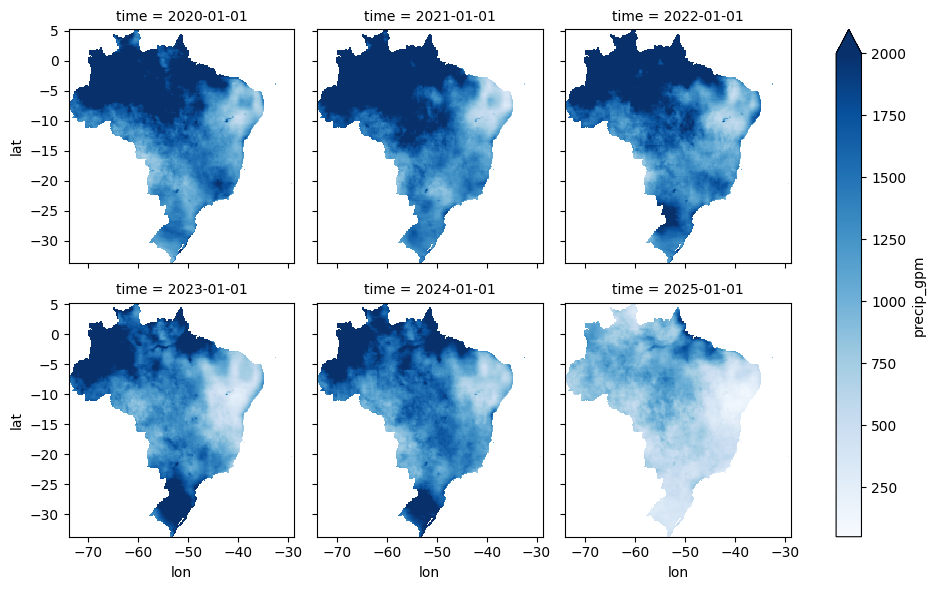

In [32]:
# gráfico: GPM
ds.precip_gpm.plot(x = 'lon',
                   y = 'lat',
                   col = 'time',
                   col_wrap = 3,
                   robust = True,
                   cmap = 'Blues',
                   vmin = 50,
                   vmax = 2000)

In [ ]:
# gráfico: CHIRPS
ds.precip_chirps.plot(x = 'lon',
                      y = 'lat',
                      col = 'time',
                      col_wrap = 3,
                      robust = True,
                      cmap = 'Blues',
                      vmin = 50,
                      vmax = 2000)

In [ ]:
# gráfico: CHIRPS para 2024
ds.precip_chirps.sel(time='2024').plot(x = 'lon',
                                       y = 'lat',
                                       col = 'time',
                                       robust = True,
                                       cmap = 'Blues',
                                       vmin = 50,
                                       vmax = 2000)